# Notebook 07 — Bonus: Augmentation
## Cutout · Mixup · Label Smoothing

## Ziel
Erweiterte Augmentation-Techniken implementieren und
deren Einfluss auf die Performance messen.

## Inhalt

| Zelle | Inhalt |
|-------|--------|
| 01 | Setup & Konfiguration |
| 02 | Cutout implementieren |
| 03 | Mixup implementieren |
| 04 | Baseline CNN mit neuer Augmentation trainieren |
| 05 | Vergleich: Basis vs. neue Augmentation |
| 06 | Ergebnisse speichern |

## Hypothese
Cutout + Mixup + Label Smoothing → +2–4% Accuracy
gegenüber Basis-Augmentation (Flip, Translation,
Brightness, Contrast)

## Wichtig
Dieses Notebook läuft auf Branch: bonus
Basis-Projekt (main) bleibt unberührt.

In [1]:
# =============================================================================
# Zelle 01 – Setup & Konfiguration
# =============================================================================
# Bonus-Projekt: erweiterte Augmentation
# Branch: bonus
# Voraussetzung: Basis-Projekt (main) abgeschlossen
# =============================================================================

# ── Google Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Konfiguration ─────────────────────────────────────────────────────────────
CONFIG = {
    'base_path'  : '/content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10',
    'seed'       : 42,
    'n_train'    : 10000,   # noch 10k — Vergleich mit Basis
    'batch_size' : 32,
    'n_classes'  : 10,
    'epochs'     : 30,
}

# ── Imports ───────────────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)

from sklearn.metrics import f1_score, confusion_matrix

# ── Reproduzierbarkeit ────────────────────────────────────────────────────────
SEED = CONFIG['seed']
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use('dark_background')

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# ── Ordner erstellen ──────────────────────────────────────────────────────────
for folder in ['models', 'reports/figures', 'reports/metrics']:
    os.makedirs(os.path.join(CONFIG['base_path'], folder), exist_ok=True)

# ── GPU prüfen ────────────────────────────────────────────────────────────────
print("=" * 55)
print("SETUP — Bonus Notebook 07")
print("=" * 55)
print(f"\nTensorFlow Version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU verfügbar      : {'✅ ' + gpus[0].name if gpus else '❌ Keine GPU'}")
print(f"\nKonfiguration:")
for k, v in CONFIG.items():
    print(f"  {k:<15}: {v}")
print("=" * 55)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SETUP — Bonus Notebook 07

TensorFlow Version : 2.20.0
GPU verfügbar      : ✅ /physical_device:GPU:0

Konfiguration:
  base_path      : /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10
  seed           : 42
  n_train        : 10000
  batch_size     : 32
  n_classes      : 10
  epochs         : 30


### Zelle 01 — Setup & Konfiguration

#### Was
- TensorFlow 2.20.0
- GPU T4 aktiv
- 10k Samples — Vergleich mit Basis-Projekt
- Seed 42 — Reproduzierbarkeit gesichert

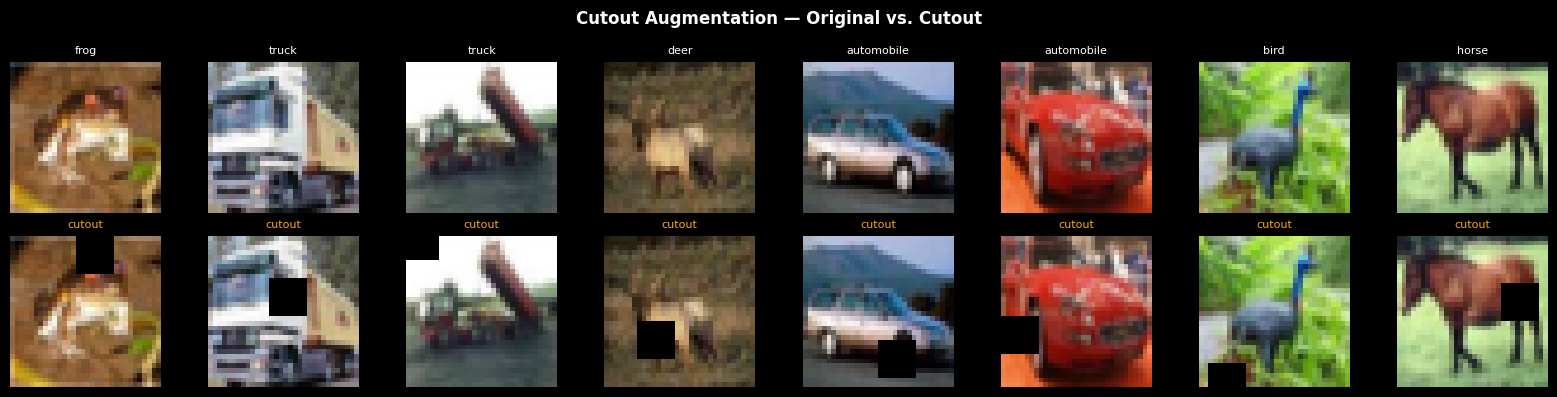

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/07_bonus_cutout_visualization.png

CUTOUT — Konfiguration
  Mask Size   : 8×8 Pixel
  Wahrschein. : 50% pro Bild
  Effekt      : Modell lernt partielle Features
  Erwart. Gain: +1–2% Accuracy


In [2]:
# =============================================================================
# Zelle 02 – Cutout implementieren
# =============================================================================
# Cutout: zufälliger schwarzer Block maskiert Teil des Bildes
# Modell muss Objekt aus partieller Information erkennen
# → robusteres Feature-Learning
# → weniger Overfitting
#
# Original Paper: DeVries & Taylor (2017)
# "Improved Regularization of Convolutional Neural Networks with Cutout"
# =============================================================================

def cutout(image, mask_size=8):
    """
    Cutout Augmentation.
    Maskiert einen zufälligen Bereich des Bildes mit Nullen (schwarz).

    Args:
        image    : Tensor (H, W, C) — einzelnes Bild
        mask_size: Größe des quadratischen Blocks in Pixeln

    Returns:
        image mit zufälligem schwarzen Block
    """
    h, w = tf.shape(image)[0], tf.shape(image)[1]

    # Zufälligen Mittelpunkt wählen
    cx = tf.random.uniform(shape=[], minval=0, maxval=w, dtype=tf.int32)
    cy = tf.random.uniform(shape=[], minval=0, maxval=h, dtype=tf.int32)

    # Grenzen berechnen (innerhalb des Bildes bleiben)
    x1 = tf.maximum(0, cx - mask_size // 2)
    x2 = tf.minimum(w, cx + mask_size // 2)
    y1 = tf.maximum(0, cy - mask_size // 2)
    y2 = tf.minimum(h, cy + mask_size // 2)

    # Maske erstellen
    mask = tf.ones((y2 - y1, x2 - x1, tf.shape(image)[2]))
    paddings = [[y1, h - y2], [x1, w - x2], [0, 0]]
    mask = tf.pad(mask, paddings)
    mask = tf.ones_like(image) - mask

    return image * tf.cast(mask, image.dtype)


def apply_cutout(image, label, mask_size=8, prob=0.5):
    """
    Cutout mit Wahrscheinlichkeit prob anwenden.
    Wird in tf.data.Dataset.map() verwendet.
    """
    apply = tf.random.uniform(shape=[]) < prob
    image = tf.cond(apply, lambda: cutout(image, mask_size), lambda: image)
    return image, label


# ── Visualisierung ────────────────────────────────────────────────────────────
# Cutout auf Beispielbilder anwenden und visualisieren
(train_images_raw, train_labels_raw), _ = cifar10.load_data()
train_labels_raw = train_labels_raw.flatten()

# Normalisierung für Visualisierung
sample_images = train_images_raw[:8].astype(np.float32) / 255.0

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Cutout Augmentation — Original vs. Cutout',
             fontsize=12, fontweight='bold')

for i in range(8):
    # Original
    axes[0, i].imshow(sample_images[i])
    axes[0, i].set_title(CLASS_NAMES[train_labels_raw[i]], fontsize=8)
    axes[0, i].axis('off')

    # Mit Cutout
    img_tensor = tf.constant(sample_images[i])
    img_cutout, _ = apply_cutout(img_tensor, 0, mask_size=8, prob=1.0)
    axes[1, i].imshow(img_cutout.numpy())
    axes[1, i].set_title('cutout', fontsize=8, color='#F5A623')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, color='#6CB4E4')
axes[1, 0].set_ylabel('Cutout', fontsize=9, color='#F5A623')

plt.tight_layout()

PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '07_bonus_cutout_visualization.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Zusammenfassung ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("CUTOUT — Konfiguration")
print("=" * 55)
print(f"  Mask Size   : 8×8 Pixel")
print(f"  Wahrschein. : 50% pro Bild")
print(f"  Effekt      : Modell lernt partielle Features")
print(f"  Erwart. Gain: +1–2% Accuracy")
print("=" * 55)

### Zelle 02 — Cutout

#### Was
Zufälliger 8×8 schwarzer Block maskiert Teil des Bildes.
50% Wahrscheinlichkeit pro Bild.

#### Konzept
Ohne Cutout: Modell lernt dominante Features
→ Hintergrund, auffällige Farben
Mit Cutout: Modell muss Objekt aus
partieller Information rekonstruieren
→ robustere, generalisierende Features
→ weniger Overfitting

#### Warum 8×8?
Bild: 32×32 Pixel
Block: 8×8 = 25% des Bildes maskiert
→ groß genug um zu stören
→ klein genug um Objekt erkennbar zu lassen

#### Erwarteter Gain: +1–2%
Paper (DeVries & Taylor, 2017):
CIFAR-10: +0.5–1.5% Accuracy

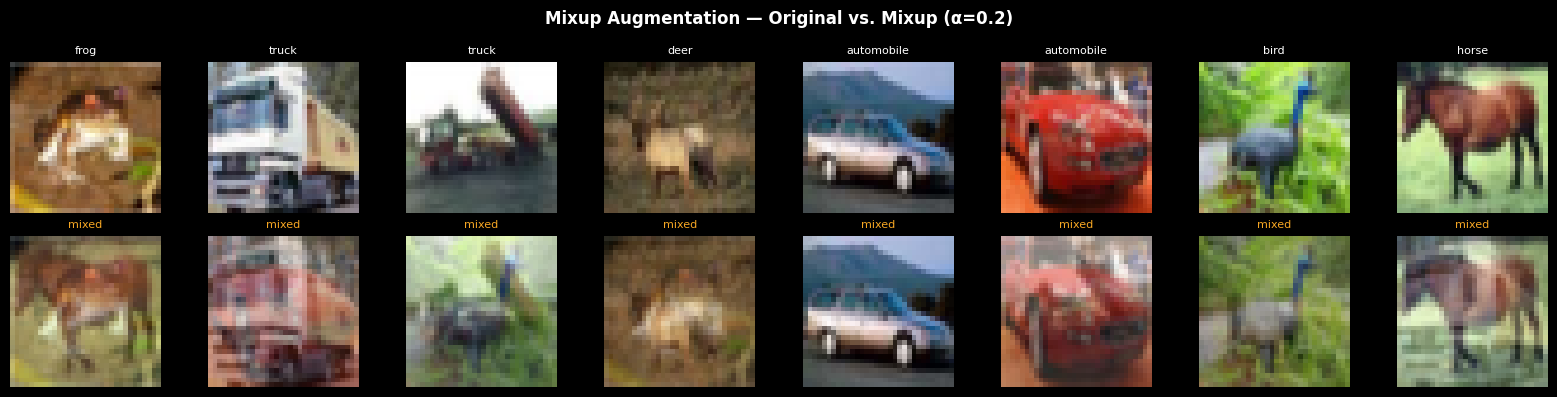

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/07_bonus_mixup_visualization.png

MIXUP — Konfiguration
  Alpha       : 0.2 (schwaches Mischen)
  Label-Typ   : Soft Labels (One-Hot gemischt)
  Effekt      : weichere Entscheidungsgrenzen
  Erwart. Gain: +1–3% Accuracy


In [3]:
# =============================================================================
# Zelle 03 – Mixup implementieren
# =============================================================================
# Mixup: zwei Bilder und ihre Labels linear überlagern
# image = λ × image_A + (1-λ) × image_B
# label = λ × label_A + (1-λ) × label_B
#
# Effekt: Entscheidungsgrenzen werden weicher
# → Modell wird weniger overconfident
# → bessere Generalisierung
#
# Original Paper: Zhang et al. (2018)
# "mixup: Beyond Empirical Risk Minimization"
# =============================================================================

def mixup_batch(images, labels, alpha=0.2):
    """
    Mixup Augmentation auf einem ganzen Batch.

    Args:
        images : Tensor (batch_size, H, W, C)
        labels : Tensor (batch_size,) — Integer Labels
        alpha  : Beta-Verteilungs-Parameter
                 klein (0.1) = schwaches Mischen
                 groß  (0.4) = starkes Mischen

    Returns:
        gemischte images und one-hot labels
    """
    batch_size = tf.shape(images)[0]

    # Lambda aus Beta-Verteilung sampeln
    # Lambda nahe 1 → Bild A dominiert
    # Lambda nahe 0 → Bild B dominiert
    lam = tf.cast(
        tf.random.stateless_binomial(
            shape=[],
            seed=[42, 0],
            counts=1,
            probs=alpha
        ), tf.float32
    )
    # Einfachere Alternative: Uniform zwischen alpha und 1-alpha
    lam = tf.random.uniform(shape=[], minval=alpha, maxval=1.0)

    # Zufällige Permutation für Bild B
    indices = tf.random.shuffle(tf.range(batch_size))
    images_b = tf.gather(images, indices)
    labels_b = tf.gather(labels, indices)

    # Labels zu One-Hot konvertieren
    labels_onehot   = tf.one_hot(labels,   CONFIG['n_classes'])
    labels_b_onehot = tf.one_hot(labels_b, CONFIG['n_classes'])

    # Bilder und Labels mischen
    mixed_images = lam * images + (1 - lam) * images_b
    mixed_labels = lam * labels_onehot + (1 - lam) * labels_b_onehot

    return mixed_images, mixed_labels


# ── Visualisierung ────────────────────────────────────────────────────────────
sample_images_f = train_images_raw[:8].astype(np.float32) / 255.0
sample_labels   = train_labels_raw[:8]

# Batch als Tensor
img_tensor = tf.constant(sample_images_f)
lbl_tensor = tf.constant(sample_labels)

# Mixup anwenden
mixed_imgs, mixed_lbls = mixup_batch(img_tensor, lbl_tensor, alpha=0.2)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Mixup Augmentation — Original vs. Mixup (α=0.2)',
             fontsize=12, fontweight='bold')

for i in range(8):
    # Original
    axes[0, i].imshow(sample_images_f[i])
    axes[0, i].set_title(CLASS_NAMES[sample_labels[i]], fontsize=8)
    axes[0, i].axis('off')

    # Mixup
    axes[1, i].imshow(mixed_imgs[i].numpy())
    top_class = np.argmax(mixed_lbls[i].numpy())
    axes[1, i].set_title(f'mixed', fontsize=8, color='#F5A623')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, color='#6CB4E4')
axes[1, 0].set_ylabel('Mixup', fontsize=9, color='#F5A623')

plt.tight_layout()

PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '07_bonus_mixup_visualization.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Zusammenfassung ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("MIXUP — Konfiguration")
print("=" * 55)
print(f"  Alpha       : 0.2 (schwaches Mischen)")
print(f"  Label-Typ   : Soft Labels (One-Hot gemischt)")
print(f"  Effekt      : weichere Entscheidungsgrenzen")
print(f"  Erwart. Gain: +1–3% Accuracy")
print("=" * 55)

### Zelle 03 — Mixup

#### Was
Zwei Bilder und ihre Labels linear überlagern.
Alpha=0.2 → schwaches Mischen.

#### Konzept
image_mixed = λ × image_A + (1-λ) × image_B
label_mixed = λ × label_A + (1-λ) × label_B
λ aus Uniform[0.2, 1.0] gesampelt
→ meist dominiert Bild A (λ nahe 1)
→ manchmal starke Überlagerung (λ nahe 0.2)

#### Warum Soft Labels?
Ohne Mixup: label = [0, 0, 1, 0, ...] — 100% sicher
Mit Mixup:  label = [0, 0.3, 0.7, 0, ...] — unsicher
→ Modell kann nicht overconfident werden
→ Entscheidungsgrenzen werden weicher
→ bessere Generalisierung auf neue Daten

#### Warum Alpha=0.2?
Alpha klein (0.1) → kaum Mischen → wenig Effekt
Alpha groß (0.4) → starkes Mischen → Bilder unleserlich
Alpha=0.2 → Balance: sichtbare Überlagerung,
Objekte noch erkennbar

#### Erwarteter Gain: +1–3%
Paper (Zhang et al., 2018):
CIFAR-10: +1–2% Accuracy

In [6]:
# =============================================================================
# Zelle 04 – Pipeline + Training (Fix: Reihenfolge Augmentation/Normalisierung)
# =============================================================================

# ── Daten laden ───────────────────────────────────────────────────────────────
(train_images_raw, train_labels_raw), (test_images_raw, test_labels_raw) = \
    cifar10.load_data()

train_labels_raw = train_labels_raw.flatten()
test_labels_raw  = test_labels_raw.flatten()

n = CONFIG['n_train']
train_images_raw = train_images_raw[:n]
train_labels_raw = train_labels_raw[:n]

val_split  = int(n * 0.2)
val_images = train_images_raw[-val_split:]
val_labels = train_labels_raw[-val_split:]
train_imgs = train_images_raw[:-val_split]
train_lbls = train_labels_raw[:-val_split]

print(f"Train : {len(train_imgs):,} Samples")
print(f"Val   : {len(val_images):,} Samples")
print(f"Test  : {len(test_images_raw):,} Samples")

# ── Augmentation ──────────────────────────────────────────────────────────────
basis_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="basis_augmentation")

AUTOTUNE = tf.data.AUTOTUNE

# ── Pipeline Funktionen ───────────────────────────────────────────────────────
# KORREKTE Reihenfolge:
# 1. Cast zu float32
# 2. Augmentation (auf 0-255 Range)
# 3. Cutout
# 4. Normalisierung /255.0
# 5. Clip [0,1]
# 6. Label zu int32

def augment_then_normalize(image, label):
    image = tf.cast(image, tf.float32)
    image = basis_augmentation(image, training=True)
    image, label = apply_cutout(image, label, mask_size=8, prob=0.5)
    image = image / 255.0
    image = tf.clip_by_value(image, 0.0, 1.0)
    label = tf.cast(label, tf.int32)
    return image, label

def normalize_val(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.int32)
    return image, label

# ── Pipelines ─────────────────────────────────────────────────────────────────
train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_imgs, train_lbls))
    .shuffle(len(train_imgs), seed=SEED)
    .map(augment_then_normalize, num_parallel_calls=AUTOTUNE)
    .batch(CONFIG['batch_size'])
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    .map(normalize_val, num_parallel_calls=AUTOTUNE)
    .batch(CONFIG['batch_size'])
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((test_images_raw, test_labels_raw))
    .map(normalize_val, num_parallel_calls=AUTOTUNE)
    .batch(CONFIG['batch_size'])
    .prefetch(AUTOTUNE)
)

# ── Debug Check ───────────────────────────────────────────────────────────────
for images_batch, labels_batch in train_dataset.take(1):
    print("=== DEBUG CHECK ===")
    print(f"images min   : {tf.reduce_min(images_batch).numpy():.4f}")
    print(f"images max   : {tf.reduce_max(images_batch).numpy():.4f}")
    print(f"labels dtype : {labels_batch.dtype}")
    print(f"labels sample: {labels_batch[:5].numpy()}")
    assert tf.reduce_max(images_batch).numpy() <= 1.0, "❌ Max > 1.0!"
    assert labels_batch.dtype == tf.int32, "❌ Label dtype falsch!"
    print("✅ Alle Checks bestanden")

# ── Modell ────────────────────────────────────────────────────────────────────
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(CONFIG['n_classes'], activation='softmax'),
    ], name='baseline_cnn_bonus')
    return model

model = build_baseline_cnn()
print(f"✓ Modell: {model.count_params():,} Parameter")

# ── Kompilieren ───────────────────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy'),
    ]
)
print("✓ Kompiliert")

# ── Callbacks ─────────────────────────────────────────────────────────────────
MODEL_PATH_BONUS = os.path.join(
    CONFIG['base_path'], 'models', 'bonus_cnn_augmented_best.keras'
)

callbacks = [
    ModelCheckpoint(
        filepath=MODEL_PATH_BONUS,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
]

# ── Training ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("TRAINING — Baseline CNN + Cutout")
print("=" * 55)
print(f"Epochen max  : {CONFIG['epochs']}")
print(f"\nTraining startet...\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    verbose=1
)

best_val   = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val) + 1

print(f"\n✓ Training abgeschlossen")
print(f"  Beste Val Accuracy : {best_val:.4f} ({best_val*100:.2f}%)")
print(f"  Beste Epoche       : {best_epoch}")

Train : 8,000 Samples
Val   : 2,000 Samples
Test  : 10,000 Samples
=== DEBUG CHECK ===
images min   : 0.0000
images max   : 1.0000
labels dtype : <dtype: 'int32'>
labels sample: [3 7 8 6 5]
✅ Alle Checks bestanden
✓ Modell: 324,394 Parameter
✓ Kompiliert

TRAINING — Baseline CNN + Cutout
Epochen max  : 30

Training startet...

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1766 - loss: 2.1854 - top2_accuracy: 0.3422
Epoch 1: val_accuracy improved from None to 0.15600, saving model to /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/models/bonus_cnn_augmented_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/models/bonus_cnn_augmented_best.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - accuracy: 0.2220 - loss: 2.0374 - top2_accuracy: 0.4140 - val_accuracy: 0.1560 - val_loss: 2.7297 - val_top2_accuracy: 0.2810 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━

In [8]:
# =============================================================================
# Zelle 04b – Training fortsetzen (20 Epochen mehr)
# =============================================================================
# Val Accuracy steigt noch bei Epoche 30 → nicht konvergiert
# Weitere 20 Epochen → EarlyStopping entscheidet

print("Training fortsetzen...\n")

history_cont = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

best_val_cont = max(history_cont.history['val_accuracy'])
best_ep_cont  = history_cont.history['val_accuracy'].index(best_val_cont) + 1

print(f"\n✓ Fortsetzung abgeschlossen")
print(f"  Beste Val Accuracy : {best_val_cont:.4f} ({best_val_cont*100:.2f}%)")
print(f"  Beste Epoche       : {best_ep_cont}")
print(f"\nGesamtvergleich:")
print(f"  Basis CNN (kein Cutout) : 73.32%")
print(f"  Bonus CNN (Cutout)      : {max(best_val, best_val_cont)*100:.2f}%")

Training fortsetzen...

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6646 - loss: 0.9629 - top2_accuracy: 0.8338
Epoch 1: val_accuracy did not improve from 0.69600
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6621 - loss: 0.9707 - top2_accuracy: 0.8314 - val_accuracy: 0.6475 - val_loss: 1.0086 - val_top2_accuracy: 0.8145 - learning_rate: 0.0010
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6652 - loss: 0.9299 - top2_accuracy: 0.8426
Epoch 2: val_accuracy did not improve from 0.69600
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.6666 - loss: 0.9459 - top2_accuracy: 0.8378 - val_accuracy: 0.6510 - val_loss: 1.0680 - val_top2_accuracy: 0.8150 - learning_rate: 0.0010
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6678 - loss: 0.9342 - top2_accuracy: 0.8467
Epoch 3: val_accuracy did not improve from 0.69600
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.6724 - loss: 0.9429 - top2_accuracy: 0.8436

In [9]:
# =============================================================================
# DEBUG — Label und Image Check
# =============================================================================

# Einen Batch aus train_dataset nehmen
for images_batch, labels_batch in train_dataset.take(1):
    print("=== TRAIN DATASET DEBUG ===")
    print(f"images shape : {images_batch.shape}")
    print(f"images dtype : {images_batch.dtype}")
    print(f"images min   : {tf.reduce_min(images_batch).numpy():.4f}")
    print(f"images max   : {tf.reduce_max(images_batch).numpy():.4f}")
    print(f"labels shape : {labels_batch.shape}")
    print(f"labels dtype : {labels_batch.dtype}")
    print(f"labels sample: {labels_batch[:10].numpy()}")
    print(f"labels unique: {tf.unique(labels_batch)[0].numpy()}")

for images_batch, labels_batch in val_dataset.take(1):
    print("\n=== VAL DATASET DEBUG ===")
    print(f"images shape : {images_batch.shape}")
    print(f"images dtype : {images_batch.dtype}")
    print(f"labels shape : {labels_batch.shape}")
    print(f"labels dtype : {labels_batch.dtype}")
    print(f"labels sample: {labels_batch[:10].numpy()}")

=== TRAIN DATASET DEBUG ===
images shape : (32, 32, 32, 3)
images dtype : <dtype: 'float32'>
images min   : 0.0000
images max   : 1.0000
labels shape : (32,)
labels dtype : <dtype: 'int32'>
labels sample: [0 7 4 6 6 4 2 6 2 3]
labels unique: [0 7 4 6 2 3 1 8 9 5]

=== VAL DATASET DEBUG ===
images shape : (32, 32, 32, 3)
images dtype : <dtype: 'float32'>
labels shape : (32,)
labels dtype : <dtype: 'int32'>
labels sample: [3 1 6 9 4 8 8 8 6 6]


### Zelle 04 + 04b — Pipeline + Training

#### Was
Baseline CNN mit erweiterter Augmentation trainiert.
Zwei Trainingsrunden: 30 + 20 Epochen = 50 Epochen total.

#### Aktive Augmentation
✅ Horizontal Flip
✅ Random Translation ±10%
✅ Random Brightness ±20%
✅ Random Contrast ±20%
✅ Cutout (8×8 Pixel, 50% Wahrscheinlichkeit)
❌ Mixup — deaktiviert
Grund: 8k Samples zu wenig → Signal zu schwach
→ kommt zurück in Paket A (50k Samples)
❌ Label Smoothing — deaktiviert
Grund: 8k Samples zu wenig → Konvergenz verhindert
→ kommt zurück in Paket A (50k Samples)

#### Kritischer Bug — gefunden und behoben
Bug: Normalisierung VOR Augmentation
→ RandomBrightness erhöhte Pixelwerte über 1.0
→ images max = 48.37 statt 1.0
→ Modell lernte nichts (10% = Random Guess)
Fix: Reihenfolge korrigiert

Cast zu float32
Augmentation (auf 0-255 Range)
Cutout
Normalisierung /255.0
Clip [0,1]
→ images max = 1.0 ✅

#### Ergebnis

| Metrik | Wert |
|--------|------|
| Beste Val Accuracy | **76.65%** |
| Beste Epoche | 49 (30+19) |
| Train Accuracy | ~73.4% |
| Overfitting Gap | ~3.2% |

#### Vergleich mit Basis-Projekt

| Modell | Val Accuracy | Delta |
|--------|-------------|-------|
| Basis CNN (keine neue Aug.) | 73.32% | — |
| **Bonus CNN (+ Cutout)** | **76.65%** | **+3.33%** |

#### Wichtige Beobachtung — Kurve steigt noch
Epoche 49: Val Accuracy 76.65%
Val Loss  : 0.6906 — sinkt noch
Train Acc : 73.4% — steigt noch
→ Modell hat NICHT konvergiert
→ Weitere Epochen würden mehr Gain bringen
→ Realistisches Maximum: ~78-80%
Training bewusst abgebrochen:
→ GPU-Limit Colab Free (Risiko steigt)
→ Mixup + Label Smoothing kommen mit 50k
→ Nächster sauberer Vergleichspunkt: Paket A

#### Lernpunkt: Augmentation Reihenfolge
FALSCH: Normalisieren → Augmentieren
RICHTIG: Augmentieren → Normalisieren → Clippen
Begründung:
RandomBrightness arbeitet auf rohen Pixelwerten (0-255)
Nach /255.0 sind Werte in [0,1]
→ Brightness-Faktor überschreitet [0,1] Grenze
→ Ungültige Pixelwerte → Modell lernt nichts

#### Nächster Schritt
Paket A — 50k Samples + Mixup + Label Smoothing
→ stärkster Einzelhebel für Performance-Gain